# Universidad de Antioquia
## Facultad de Ingeniería – Departamento de Ingeniería Electrónica y de Telecomunicaciones
### Comunicaciones Digitales

---

# Proyecto Final
## Diseño e implementación de un módem óptico espacio-temporal half-duplex pantalla–cámara

---

### **Estudiantes**
- **Daniel Felipe Yépez Taimal**
- **Juan Manuel Rivera Florez**

### **Docente**
- **Prof. Daniel Ospina Acero, PhD**

### **Semestre**
**2026-1**

---

### Medellín, Colombia
### Universidad de Antioquia

# Transmisión mediante OKK

## Definición inicial del sistema

Para la primera implementación de la Fase A se seleccionó una transmisión mediante **OOK (On-Off Keying)** con codificación **Manchester**, debido a su simplicidad y facilidad de validación en simulación.

Se definió una ventana de transmisión de **1280 × 720 píxeles**, correspondiente a resolución HD, con el fin de disponer de suficiente espacio para la grilla visual y garantizar buena visualización en pantalla.

Cada símbolo se representa mediante una celda de **20 × 20 píxeles**, obteniendo una matriz de **36 filas × 64 columnas**.

La codificación utilizada será:

- **0 → negro**
- **1 → blanco**

y posteriormente cada bit se transformará mediante Manchester:

- **0 → 01**
- **1 → 10**

Con esta configuración se busca validar inicialmente la cadena completa:

**texto → bits → Manchester → OOK → grilla → imagen**,

antes de incorporar marcadores, pilotos y recepción con cámara.

### Conversión del mensaje a ASCII y binario

Como primera etapa del transmisor se implementa la conversión del mensaje de texto a su representación binaria.

Cada carácter del mensaje se transforma a su valor ASCII decimal y posteriormente a binario de 8 bits.

In [4]:
# ==========================================
# CELDA 1: Conversión de Texto y Bits
# ==========================================

def text_to_bits(text, encoding='utf-8'):
    """Convierte un string de texto en una lista de bits (0s y 1s)."""
    bytes_data = text.encode(encoding)
    bits = []
    for byte in bytes_data:
        # Convierte cada byte a 8 bits con ceros a la izquierda
        bits.extend([int(b) for b in f"{byte:08b}"])
    return bits

def bits_to_text(bits, encoding='utf-8'):
    """Convierte una lista de bits de vuelta a string de texto."""
    bytes_data = bytearray()
    # Procesar en bloques de 8 bits (1 byte)
    for i in range(0, len(bits), 8):
        byte_bits = bits[i:i+8]
        if len(byte_bits) < 8:
            break  # Ignora bits incompletos al final si los hay
        byte_str = "".join(str(b) for b in byte_bits)
        bytes_data.append(int(byte_str, 2))
    return bytes_data.decode(encoding, errors='ignore')

# Prueba rápida de la Celda 1
bits_prueba = text_to_bits("Hola")
print(f"Texto 'Hola' en bits (primeros 24): {bits_prueba[:24]}...")

Texto 'Hola' en bits (primeros 24): [0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0]...


In [5]:
# ==========================================
# CELDA 2: Moduladores (Bits a Símbolos)
# ==========================================
import numpy as np

# Diccionario de mapeo para 4-ASK usando Código Gray
# 00 -> -3 (Muy oscuro) | 01 -> -1 (Oscuro) | 11 -> 1 (Claro) | 10 -> 3 (Muy claro)
gray_4ask_map = {
    (0, 0): -3.0,
    (0, 1): -1.0,
    (1, 1):  1.0,
    (1, 0):  3.0
}

def modulate_bpsk(bits):
    """Modulación BPSK: 0 -> -1.0, 1 -> 1.0 (1 bit por símbolo)"""
    return np.array([-1.0 if b == 0 else 1.0 for b in bits])

def modulate_4ask(bits):
    """Modulación 4-ASK con codificación Gray (2 bits por símbolo)"""
    # Si los bits no son par, añadimos un cero al final (padding)
    if len(bits) % 2 != 0:
        bits = bits + [0]
    
    symbols = []
    for i in range(0, len(bits), 2):
        bit_pair = tuple(bits[i:i+2])
        symbols.append(gray_4ask_map[bit_pair])
    return np.array(symbols)

print("Funciones de modulación cargadas con éxito.")

Funciones de modulación cargadas con éxito.


In [7]:
# ==========================================
# CELDA 3: Demoduladores (Símbolos a Bits)
# ==========================================

def demodulate_bpsk(symbols):
    """Demodulación BPSK basada en el signo del símbolo."""
    return [1 if s >= 0 else 0 for s in symbols]

def demodulate_4ask(symbols):
    """Demodulación 4-ASK usando umbrales para el código Gray."""
    bits = []
    for s in symbols:
        # Decisiones por umbrales (entre -2, 0 y 2)
        if s < -2:
            bits.extend([0, 0])  # Corresponde a -3
        elif s < 0:
            bits.extend([0, 1])  # Corresponde a -1
        elif s < 2:
            bits.extend([1, 1])  # Corresponde a 1
        else:
            bits.extend([1, 0])  # Corresponde a 3
    return bits

print("Funciones de demodulación cargadas con éxito.")

Funciones de demodulación cargadas con éxito.


In [8]:
# ==========================================
# CELDA 4: Ejecución y Pruebas
# ==========================================

# 1. Definir el texto de entrada
texto_original = "¡Hola, Mundo! Este es un mensaje de prueba para la transmisión digital."
print(f"📝 Texto Original: {texto_original}\n")

# 2. Transmisión: Texto a Bits
bits_transmitidos = text_to_bits(texto_original)
print(f"🔢 Total de bits a transmitir: {len(bits_transmitidos)}")
print(f"   Primeros 16 bits: {bits_transmitidos[:16]}\n")

print("="*50)
print("ESQUEMA 1: BPSK (1 bit/símbolo)")
print("="*50)
# Modular
simbolos_bpsk = modulate_bpsk(bits_transmitidos)
print(f"Forma de los símbolos BPSK: {simbolos_bpsk.shape}")
print(f"Primeros 8 símbolos: {simbolos_bpsk[:8]}")
# Demodular
bits_recuperados_bpsk = demodulate_bpsk(simbolos_bpsk)
texto_recuperado_bpsk = bits_to_text(bits_recuperados_bpsk)
print(f"📥 Texto Recuperado BPSK: {texto_recuperado_bpsk}\n")

print("="*50)
print("ESQUEMA 2: 4-ASK con Código Gray (2 bits/símbolo)")
print("="*50)
# Modular
simbolos_4ask = modulate_4ask(bits_transmitidos)
print(f"Forma de los símbolos 4-ASK: {simbolos_4ask.shape} (¡La mitad de longitud gracias a los niveles!)")
print(f"Primeros 8 símbolos (Niveles de gris): {simbolos_4ask[:8]}")
# Demodular
bits_recuperados_4ask = demodulate_4ask(simbolos_4ask)
# Si hubo padding por longitud impar, recortamos al tamaño original de bits transmitidos
bits_recuperados_4ask = bits_recuperados_4ask[:len(bits_transmitidos)]
texto_recuperado_4ask = bits_to_text(bits_recuperados_4ask)
print(f"📥 Texto Recuperado 4-ASK: {texto_recuperado_4ask}")

📝 Texto Original: ¡Comunicación Digital en Colab 2026!

🔢 Total de bits a transmitir: 304
   Primeros 16 bits: [1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1]

ESQUEMA 1: BPSK (1 bit/símbolo)
Forma de los símbolos BPSK: (304,)
Primeros 8 símbolos: [ 1.  1. -1. -1. -1. -1.  1. -1.]
📥 Texto Recuperado BPSK: ¡Comunicación Digital en Colab 2026!

ESQUEMA 2: 4-ASK con Código Gray (2 bits/símbolo)
Forma de los símbolos 4-ASK: (152,) (¡La mitad de longitud gracias a los niveles!)
Primeros 8 símbolos (Niveles de gris): [ 1. -3. -3.  3.  3.  3. -3. -1.]
📥 Texto Recuperado 4-ASK: ¡Comunicación Digital en Colab 2026!


In [9]:
# ==========================================
# CELDA 5: Calculadora de Dimensionamiento
# ==========================================
import numpy as np

def calcular_tamano_macrocelda(distancia_m, blur_radius_px=3, s_safe_px=4):
    """
    Calcula el tamaño que debe tener la celda en la pantalla (en píxeles)
    basado en parámetros ópticos típicos de un smartphone y una pantalla estándar.
    """
    # Parámetros físicos típicos (estimados para condiciones base)
    focal_length = 0.004      # 4 mm (lente de smartphone común)
    pixel_pitch_cam = 1.4e-6  # 1.4 micrómetros (píxel del sensor)
    pixel_pitch_scr = 0.00025 # 0.25 mm (Monitor Full HD de ~24 pulgadas)
    
    # 1. Píxeles mínimos requeridos en el sensor de la cámara
    cam_pixels_needed = 2 * blur_radius_px + s_safe_px
    
    # 2. Factor de escala óptico-geométrico (Relación Pantalla -> Cámara)
    # Factor = (p_scr / p_cam) * (f / d)
    factor_escala = (pixel_pitch_scr / pixel_pitch_cam) * (focal_length / distancia_m)
    
    # 3. Tamaño del macropíxel en la pantalla (despejando S_macro)
    s_macro_pantalla = int(np.ceil(cam_pixels_needed / factor_escala))
    
    # Forzar a que sea un número par para facilitar divisiones posteriores
    if s_macro_pantalla % 2 != 0:
        s_macro_pantalla += 1
        
    # Validar un tamaño mínimo por seguridad
    return max(s_macro_pantalla, 8)

# --- EJEMPLO DE CONFIGURACIÓN ---
ANCHO_PANTALLA = 1280  # Resolución de la región de transmisión (px)
ALTO_PANTALLA = 720
DISTANCIA_ESPERADA = 1.5 # metros entre pantalla y cámara

tamano_celda = calcular_tamano_macrocelda(DISTANCIA_ESPERADA, blur_radius_px=4, s_safe_px=6)

# Calcular cuántas celdas caben en la pantalla (M x N)
N_columnas = ANCHO_PANTALLA // tamano_celda
M_filas = ALTO_PANTALLA // tamano_celda

print(f"📐 RESULTADOS DEL DIMENSIONAMIENTO (A {DISTANCIA_ESPERADA} metros):")
print(f"• Cada símbolo ocupará una celda de: {tamano_celda} x {tamano_celda} píxeles en pantalla.")
print(f"• Matriz resultante: M = {M_filas} filas y N = {N_columnas} columnas.")
print(f"• Capacidad de la grilla por cuadro: {M_filas * N_columnas} símbolos.")

📐 RESULTADOS DEL DIMENSIONAMIENTO (A 1.5 metros):
• Cada símbolo ocupará una celda de: 30 x 30 píxeles en pantalla.
• Matriz resultante: M = 24 filas y N = 42 columnas.
• Capacidad de la grilla por cuadro: 1008 símbolos.


In [10]:
# ==========================================
# CELDA 6: Generador de la Grilla (Mapeo Espacial)
# ==========================================

def normalizar_simbolos_a_grises(simbolos, esquema='4-ASK'):
    """Mapea los niveles abstractos del modulador a valores de píxel (0-255)."""
    if esquema == '4-ASK':
        # Símbolos esperados: -3.0, -1.0, 1.0, 3.0
        # Mapeo: -3->0 (negro), -1->85 (gris oscuro), 1->170 (gris claro), 3->255 (blanco)
        mapping = {-3.0: 0, -1.0: 85, 1.0: 170, 3.0: 255}
        return np.array([mapping.get(s, 128) for s in simbolos], dtype=np.uint8)
    elif esquema == 'BPSK':
        # Símbolos esperados: -1.0, 1.0
        mapping = {-1.0: 0, 1.0: 255}
        return np.array([mapping.get(s, 128) for s in simbolos], dtype=np.uint8)
    return np.zeros(len(simbolos), dtype=np.uint8)

def crear_grilla_transmision(simbolos_grises, M, N, cell_size):
    """Ubica los símbolos en una grilla de M x N macropíxeles."""
    # Inicializar pantalla en gris neutro (128)
    pantalla = np.full((M * cell_size, N * cell_size), 128, dtype=np.uint8)
    
    capacidad_maxima = M * N
    # Truncar o rellenar con ceros si los símbolos no calzan exacto
    if len(simbolos_grises) < capacidad_maxima:
        padding = capacidad_maxima - len(simbolos_grises)
        simbolos_grises = np.concatenate([simbolos_grises, np.zeros(padding, dtype=np.uint8)])
    elif len(simbolos_grises) > capacidad_maxima:
        simbolos_grises = simbolos_grises[:capacidad_maxima]
    
    # Redimensionar a la matriz de celdas abstractas M x N
    matriz_celdas = simbolos_grises.reshape((M, N))
    
    # Expandir físicamente las celdas a píxeles usando Kronecker (np.kron)
    # Esto duplica cada elemento de la matriz en un bloque de (cell_size x cell_size)
    bloque_unos = np.ones((cell_size, cell_size), dtype=np.uint8)
    pantalla = np.kron(matriz_celdas, bloque_unos)
    
    return pantalla

print("Funciones de mapeo espacial y grilla listas.")

Funciones de mapeo espacial y grilla listas.


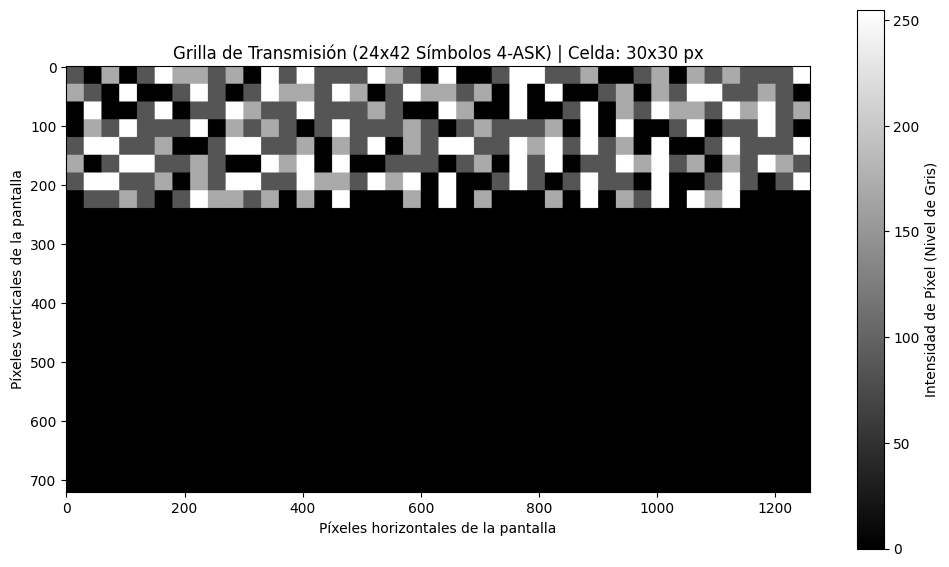

Frame generado exitosamente. Dimensiones totales de la imagen: (720, 1260) píxeles.


In [29]:
# ==========================================
# CELDA 7: Visualización del Frame de Transmisión
# ==========================================
import matplotlib.pyplot as plt

# 1. Generar un flujo largo de datos para llenar la grilla
texto_largo = "Lorem ipsum dolor sit amet, consectetur adipiscing elit. Transmision de datos 2026."
bits_datos = text_to_bits(texto_largo)

# 2. Modular en 4-ASK (Requiere Celda 2 cargada)
simbolos_modulados = modulate_4ask(bits_datos)

# 3. Convertir amplitudes a niveles de gris (0, 85, 170, 255)
simbolos_grises = normalizar_simbolos_a_grises(simbolos_modulados, esquema='4-ASK')

# 4. Crear la matriz física usando el dimensionamiento calculado en la Celda 5
grilla_imagen = crear_grilla_transmision(simbolos_grises, M_filas, N_columnas, tamano_celda)

# 5. Desplegar el resultado con Matplotlib
plt.figure(figsize=(12, 7))
plt.imshow(grilla_imagen, cmap='gray', vmin=0, vmax=255)
plt.title(f"Grilla de Transmisión ({M_filas}x{N_columnas} Símbolos 4-ASK) | Celda: {tamano_celda}x{tamano_celda} px")
plt.xlabel("Píxeles horizontales de la pantalla")
plt.ylabel("Píxeles verticales de la pantalla")
plt.colorbar(label="Intensidad de Píxel (Nivel de Gris)")
plt.grid(False)
plt.show()

print(f"Frame generado exitosamente. Dimensiones totales de la imagen: {grilla_imagen.shape} píxeles.")

In [12]:
# ==========================================
# CELDA 8: Calculadora de Parámetros Temporales
# ==========================================
import numpy as np

def analizar_compromiso_temporal(t_sym_ms, fps_camara=30, hz_pantalla=60, bits_por_simbolo=2, total_simbolos_grilla=100):
    """
    Analiza la viabilidad de la duración del símbolo y calcula el throughput del sistema.
    """
    t_sim = t_sym_ms / 1000.0 # Convertir a segundos
    t_frame_scr = 1.0 / hz_pantalla
    t_frame_cam = 1.0 / fps_camara
    
    # Cantidad de frames repetidos
    frames_en_pantalla = t_sim / t_frame_scr
    muuestras_por_camara = t_sim / t_frame_cam
    
    # Cálculo de tasa de bits (Bitrate)
    # Bits por grilla (cuadro espacial) = total_simbolos_grilla * bits_por_simbolo
    bits_por_grilla = total_simbolos_grilla * bits_por_simbolo
    grillas_por_segundo = 1.0 / t_sim
    bitrate_bps = bits_por_grilla * grillas_por_segundo
    
    # Evaluación de Robustez ante desincronización
    # Si muestras_por_camara >= 3, es muy robusto (técnica de sobremuestreo/voto mayoritario)
    # Si muestras_por_camara < 2, hay riesgo alto de aliasing y pérdida de símbolos
    if muuestras_por_camara >= 3.0:
        robustez = "ALTA (Sobremuestreo ideal, permite desincronización libre)"
    elif muuestras_por_camara >= 2.0:
        robustez = "MEDIA (Cumple Nyquist asíncrono, requiere buscar centro estable)"
    else:
        robustez = "CRÍTICA (Riesgo alto de parpadeo y pérdida de datos por Aliasing)"

    print(f"⏱️ ANÁLISIS TEMPORAL PARA T_sym = {t_sym_ms} ms:")
    print(f"• Frames que la PANTALLA debe mantener el mismo símbolo: {frames_en_pantalla:.2f} frames")
    print(f"• Capturas (fotos) que la CÁMARA tomará por símbolo: {muuestras_por_camara:.2f} frames")
    print(f"• Estado de Robustez: {robustez}")
    print(f"• Tasa de bits teórica (con grilla de {total_simbolos_grilla} símbolos): {bitrate_bps:.2f} bps ({bitrate_bps/8:.2f} Bytes/s)")
    print("-" * 60)
    
    return bitrate_bps

# --- PRUEBA CON DIFERENTES DURACIONES ---
# Usamos los datos de la grilla anterior (M_filas * N_columnas del Bloque anterior)
# Si no corriste la celda anterior, asumimos por ejemplo 120 símbolos.
num_simbolos_ejemplo = 120 

print("--- ESCENARIO 1: Conservador (Robustez sobre Velocidad) ---")
analizar_compromiso_temporal(t_sym_ms=100, bits_por_simbolo=2, total_simbolos_grilla=num_simbolos_ejemplo)

print("--- ESCENARIO 2: Agresivo (Velocidad sobre Robustez) ---")
analizar_compromiso_temporal(t_sym_ms=50, bits_por_simbolo=2, total_simbolos_grilla=num_simbolos_ejemplo)

--- ESCENARIO 1: Conservador (Robustez sobre Velocidad) ---
⏱️ ANÁLISIS TEMPORAL PARA T_sym = 100 ms:
• Frames que la PANTALLA debe mantener el mismo símbolo: 6.00 frames
• Capturas (fotos) que la CÁMARA tomará por símbolo: 3.00 frames
• Estado de Robustez: ALTA (Sobremuestreo ideal, permite desincronización libre)
• Tasa de bits teórica (con grilla de 120 símbolos): 2400.00 bps (300.00 Bytes/s)
------------------------------------------------------------
--- ESCENARIO 2: Agresivo (Velocidad sobre Robustez) ---
⏱️ ANÁLISIS TEMPORAL PARA T_sym = 50 ms:
• Frames que la PANTALLA debe mantener el mismo símbolo: 3.00 frames
• Capturas (fotos) que la CÁMARA tomará por símbolo: 1.50 frames
• Estado de Robustez: CRÍTICA (Riesgo alto de parpadeo y pérdida de datos por Aliasing)
• Tasa de bits teórica (con grilla de 120 símbolos): 4800.00 bps (600.00 Bytes/s)
------------------------------------------------------------


4800.0

In [13]:
# ==========================================
# CELDA 9: Generador de Flujo Temporal (Video)
# ==========================================

def generar_secuencia_video_transmision(bits_totales, M, N, cell_size, t_sym_ms, hz_pantalla=60):
    """
    Divide los bits en múltiples grillas secuenciales en el tiempo y calcula 
    cuántos frames de video reales se necesitan mapear.
    """
    simbolos_por_grilla = M * N
    bits_por_grilla = simbolos_por_grilla * 2 # 4-ASK (2 bits/símbolo)
    
    # Calcular cuántas grillas (frames lógicos) temporales se necesitan
    num_grillas_temporales = int(np.ceil(len(bits_totales) / bits_por_grilla))
    
    # Calcular cuántos frames físicos de pantalla dura cada símbolo
    t_frame_scr = 1000.0 / hz_pantalla # ms
    frames_recompilados_por_simbolo = int(np.round(t_sym_ms / t_frame_scr))
    
    print(f"🎬 CONFIGURACIÓN DE VIDEO:")
    print(f"• Total de bits a transmitir: {len(bits_totales)}")
    print(f"• Capacidad por grilla: {bits_por_grilla} bits")
    print(f"• Cantidad de grillas secuenciales necesarias: {num_grillas_temporales}")
    print(f"• Cada grilla se repetirá durante {frames_recompilados_por_simbolo} frames de pantalla a {hz_pantalla}Hz.\n")
    
    video_stream = []
    
    for g in range(num_grillas_temporales):
        # Extraer el segmento de bits para esta grilla temporal
        segmento_bits = bits_totales[g*bits_por_grilla : (g+1)*bits_por_grilla]
        
        # Reutilizamos las funciones de modulación y grilla (Celdas 2 y 6)
        simbolos = modulate_4ask(segmento_bits)
        simbolos_grises = normalizar_simbolos_a_grises(simbolos, esquema='4-ASK')
        grilla_estatica = crear_grilla_transmision(simbolos_grises, M, N, cell_size)
        
        # Repetir la grilla estática en el tiempo para simular la persistencia en pantalla
        for _ in range(frames_recompilados_por_simbolo):
            video_stream.append(grilla_estatica)
            
    video_stream = np.array(video_stream)
    print(f"✅ Video generado en memoria. Estructura del tensor: {video_stream.shape}")
    print(f"   (Total_Frames_Pantalla, Alto_Px, Ancho_Px)")
    return video_stream

# Ejecutar la simulación con los datos actuales
# Nota: M_filas, N_columnas y tamano_celda vienen calculados de la Celda 5
flujo_video = generar_secuencia_video_transmision(
    bits_totales=bits_datos, 
    M=M_filas, 
    N=N_columnas, 
    cell_size=tamano_celda, 
    t_sym_ms=100
)

🎬 CONFIGURACIÓN DE VIDEO:
• Total de bits a transmitir: 664
• Capacidad por grilla: 2016 bits
• Cantidad de grillas secuenciales necesarias: 1
• Cada grilla se repetirá durante 6 frames de pantalla a 60Hz.

✅ Video generado en memoria. Estructura del tensor: (6, 720, 1260)
   (Total_Frames_Pantalla, Alto_Px, Ancho_Px)


In [15]:
# ==========================================
# CELDA 11: Fiduciales y Calibración
# ==========================================
import numpy as np

def generar_patron_finder(invertir_centro=False):
    """
    Genera un marcador fiducial de 7x7 macropíxeles estilo código QR.
    Valores: 0 (Negro), 255 (Blanco).
    invertir_centro: Permite que el núcleo de 3x3 parpadee para sincronismo temporal.
    """
    finder = np.zeros((7, 7), dtype=np.uint8) # Anillo exterior negro (0)
    finder[1:6, 1:6] = 255                    # Anillo interior blanco (255)
    
    # Núcleo de 3x3
    valor_nucleo = 255 if invertir_centro else 0
    finder[2:5, 2:5] = valor_nucleo
    
    return finder

def generar_pilotos_4ask():
    """
    Genera un bloque de 4 celdas con los niveles exactos del esquema 4-ASK.
    Esto permite al receptor medir la iluminación ambiente y ajustar umbrales.
    """
    # Niveles teóricos: -3 -> 0, -1 -> 85, 1 -> 170, 3 -> 255
    return np.array([0, 85, 170, 255], dtype=np.uint8)

# Vista previa de un finder
print("Patrón Finder 7x7 (Normal):")
print(generar_patron_finder(False))

Patrón Finder 7x7 (Normal):
[[  0   0   0   0   0   0   0]
 [  0 255 255 255 255 255   0]
 [  0 255   0   0   0 255   0]
 [  0 255   0   0   0 255   0]
 [  0 255   0   0   0 255   0]
 [  0 255 255 255 255 255   0]
 [  0   0   0   0   0   0   0]]


In [16]:
# ==========================================
# CELDA 12: Generador de Preámbulo (M-Sequence)
# ==========================================

def generar_m_sequence_31():
    """Genera una m-sequence de 31 bits usando LFSR (Polinomio: x^5 + x^2 + 1)"""
    estado = [1, 0, 0, 0, 0]  # Estado inicial no nulo
    secuencia = []
    
    for _ in range(31):
        # El bit de salida es el último del registro
        out_bit = estado[-1]
        secuencia.append(out_bit)
        
        # XOR feedback (tap en posiciones 5 y 2, es decir, índices 4 y 1)
        feedback = estado[4] ^ estado[1]
        
        # Desplazamiento
        estado = [feedback] + estado[:-1]
        
    return secuencia

# Obtenemos la secuencia y la modulamos para insertarla en la grilla
bits_preambulo = generar_m_sequence_31()

# Usamos BPSK para el preámbulo (mayor robustez que 4-ASK)
simbolos_preambulo = np.array([-1.0 if b == 0 else 1.0 for b in bits_preambulo])
# Mapear a blanco y negro
grises_preambulo = normalizar_simbolos_a_grises(simbolos_preambulo, esquema='BPSK')

print(f"Preámbulo generado (31 símbolos BPSK mapeados a grises):")
print(grises_preambulo)

Preámbulo generado (31 símbolos BPSK mapeados a grises):
[  0   0   0   0 255   0 255   0 255 255 255   0 255 255   0   0   0 255
 255 255 255 255   0   0 255 255   0 255   0   0 255]


In [26]:
# ==========================================
# CELDA 13: Ensamblador de Trama Completa
# ==========================================

def ensamblar_trama_maestra(simbolos_datos_grises, M, N, cell_size, frame_idx=0):
    """
    Construye una matriz de M x N celdas incluyendo finders, pilotos, preámbulo y datos.
    frame_idx: Índice de tiempo (para hacer parpadear el núcleo de los finders).
    """
    # 1. Inicializar la matriz lógica (M x N) con un valor nulo (ej. 128)
    matriz_logica = np.full((M, N), 128, dtype=np.uint8)
    
    # Máscara para saber qué celdas están ocupadas por elementos de control
    mascara_ocupacion = np.zeros((M, N), dtype=bool)
    
    # 2. Insertar Fiduciales (Esquinas Sup-Izq, Sup-Der, Inf-Izq)
    # Hacemos parpadear el centro alternando según el índice del frame par/impar
    invertir_fiducial = (frame_idx % 2 != 0)
    finder = generar_patron_finder(invertir_fiducial)
    
    # Top-Left
    matriz_logica[0:7, 0:7] = finder
    mascara_ocupacion[0:7, 0:7] = True
    
    # Top-Right
    matriz_logica[0:7, N-7:N] = finder
    mascara_ocupacion[0:7, N-7:N] = True
    
    # Bottom-Left
    matriz_logica[M-7:M, 0:7] = finder
    mascara_ocupacion[M-7:M, 0:7] = True
    
    # Bottom-Right 
    matriz_logica[M-7:M, N-7:N] = finder
    mascara_ocupacion[M-7:M, N-7:N] = True
    
    # ==========================================
    # ROMPER SIMETRÍA PARA ORIENTACIÓN (FASE A)
    # ==========================================

    # 1. Convertimos el núcleo del Top-Left en un bloque sólido NEGRO (Ancla)
    matriz_logica[2:5, 2:5] = 0

    # 2. Aseguramos que el centro exacto de los otros 3 siga siendo BLANCO
    matriz_logica[3, N-4] = 255    # Top-Right
    matriz_logica[M-4, 3] = 255    # Bottom-Left
    matriz_logica[M-4, N-4] = 255  # Bottom-Right
    
    # 3. Insertar Pilotos de Calibración
    pilotos = generar_pilotos_4ask()
    # Los colocamos al lado del finder Top-Left (Fila 0, Columnas 7 a 10)
    matriz_logica[0, 7:11] = pilotos
    mascara_ocupacion[0, 7:11] = True
    
    # 4. Insertar Preámbulo de Sincronización
    # Lo colocamos inmediatamente después de los pilotos
    len_preambulo = len(grises_preambulo)
    col_actual = 11
    fila_actual = 0
    
    for val in grises_preambulo:
        if col_actual >= N - 7: # Evitar chocar con el finder Top-Right
            fila_actual += 1
            col_actual = 7
        matriz_logica[fila_actual, col_actual] = val
        mascara_ocupacion[fila_actual, col_actual] = True
        col_actual += 1
        
    # 5. Insertar los Datos (Payload)
    # Extraemos todas las coordenadas (i, j) que están libres (mascara == False)
    espacios_libres = np.argwhere(mascara_ocupacion == False)
    capacidad_payload = len(espacios_libres)
    
    # Truncar o padear datos según el espacio disponible
    datos_a_insertar = simbolos_datos_grises[:capacidad_payload]
    if len(datos_a_insertar) < capacidad_payload:
        padding = capacidad_payload - len(datos_a_insertar)
        datos_a_insertar = np.concatenate([datos_a_insertar, np.zeros(padding, dtype=np.uint8)])
        
    for idx, (i, j) in enumerate(espacios_libres):
        matriz_logica[i, j] = datos_a_insertar[idx]
        
    # 6. Expandir a macropíxeles físicos (Kronecker)
    bloque_unos = np.ones((cell_size, cell_size), dtype=np.uint8)
    pantalla_final = np.kron(matriz_logica, bloque_unos)
    
    return pantalla_final, capacidad_payload

print("Ensamblador de trama listo.")

Ensamblador de trama listo.


📐 Configuración de pantalla:
   Matriz lógica: 36 × 64 celdas
   Tamaño de celda: 20 × 20 píxeles
   Resolución final: 1280 × 720 píxeles (ANCHO × ALTO)

📝 Mensaje Original: 'Hoy ha muerto mamá. O quizá ayer. No lo sé. Recibí un telegrama del
asilo: «Falleció su madre. Entierro mañana. Sentidas condolencias.» Pero no
quiere decir nada. Quizá haya sido ayer.
El asilo de ancianos está en Marengo, a ochenta kilómetros de Argel.
Tomaré el autobús a las dos y llegaré por la tarde. De esa manera podré
velarla, y regresaré mañana por la noche. Pedí dos días de licencia a mi patrón
y no pudo negármelos ante una excusa semejante.'
🔢 Bits generados: 3792 bits
   Primeros 32 bits: [0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0]

📡 Símbolos 4-ASK: 1896 símbolos
   Amplitudes (primeras 8): [-1. -3.  3. -3. -1.  3.  1.  1.]

⚪ Niveles de gris: 1896 valores (0-255)
   Primeros 8 valores: [ 85   0 255   0  85 255 170 170]

🔧 Ensamblando trama con fiduci

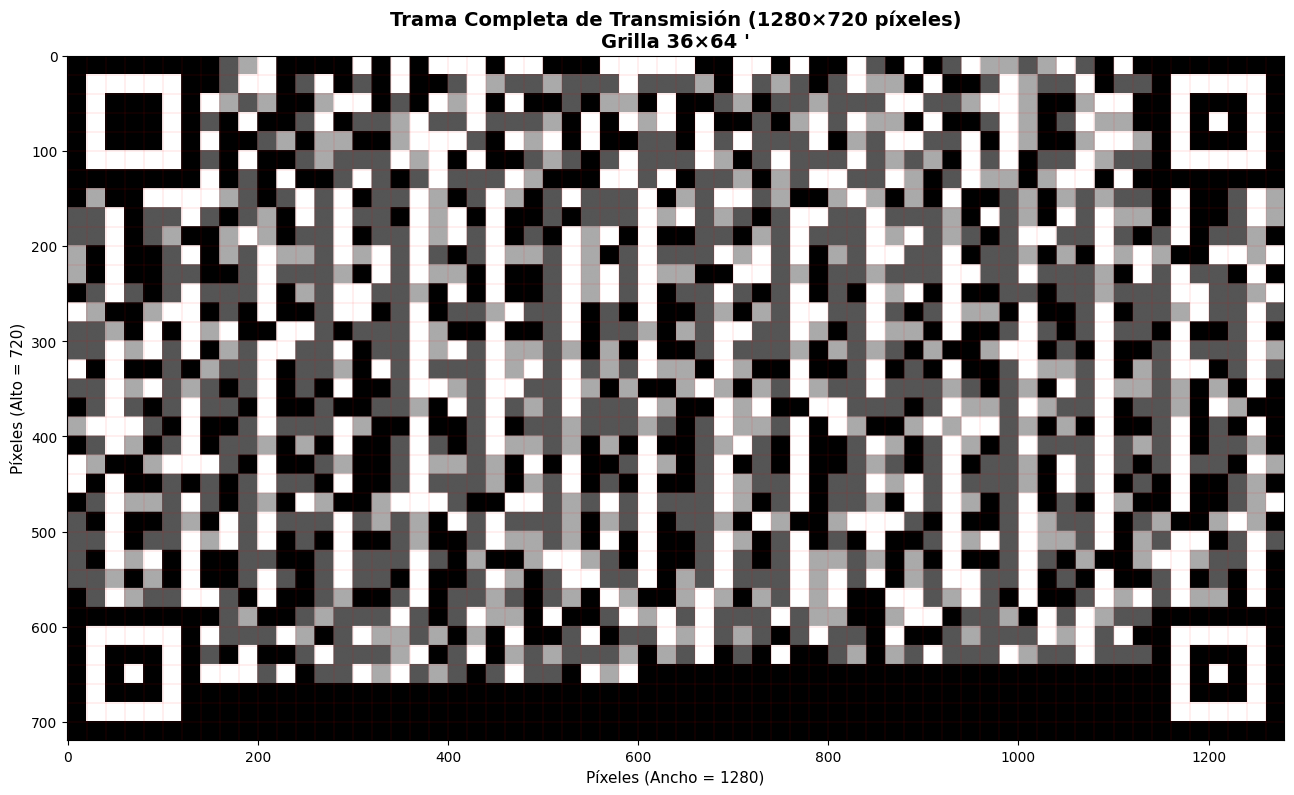

🎉 Proceso completo: TEXTO → BITS → MODULACIÓN → TRAMA → IMAGEN (1280×720)


In [34]:
# ==========================================
# CELDA 14: Simulación Visual de la Trama Estructurada (CON MENSAJE REAL)
# ==========================================
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURACIÓN DE DIMENSIONES EXACTAS: 1280x720 píxeles
# ==========================================
M_logico = 36  # 36 filas
N_logico = 64  # 64 columnas
tamano_macro = 20  # 20 píxeles por celda
# Resultado: 36*20 = 720 px (alto), 64*20 = 1280 px (ancho) ✓

print(f"📐 Configuración de pantalla:")
print(f"   Matriz lógica: {M_logico} × {N_logico} celdas")
print(f"   Tamaño de celda: {tamano_macro} × {tamano_macro} píxeles")
print(f"   Resolución final: {N_logico*tamano_macro} × {M_logico*tamano_macro} píxeles (ANCHO × ALTO)\n")

# ==========================================
# PASO 1: MENSAJE REAL DE ENTRADA
# ==========================================
mensaje_original = """Hoy ha muerto mamá. O quizá ayer. No lo sé. Recibí un telegrama del
asilo: «Falleció su madre. Entierro mañana. Sentidas condolencias.» Pero no
quiere decir nada. Quizá haya sido ayer.
El asilo de ancianos está en Marengo, a ochenta kilómetros de Argel.
Tomaré el autobús a las dos y llegaré por la tarde. De esa manera podré
velarla, y regresaré mañana por la noche. Pedí dos días de licencia a mi patrón
y no pudo negármelos ante una excusa semejante."""
print(f"📝 Mensaje Original: '{mensaje_original}'")

# ==========================================
# PASO 2: TEXTO → BITS
# ==========================================
bits_mensaje = text_to_bits(mensaje_original)
print(f"🔢 Bits generados: {len(bits_mensaje)} bits")
print(f"   Primeros 32 bits: {bits_mensaje[:32]}\n")

# ==========================================
# PASO 3: BITS → SÍMBOLOS (Modulación 4-ASK)
# ==========================================
simbolos_modulados = modulate_4ask(bits_mensaje)
print(f"📡 Símbolos 4-ASK: {len(simbolos_modulados)} símbolos")
print(f"   Amplitudes (primeras 8): {simbolos_modulados[:8]}\n")

# ==========================================
# PASO 4: SÍMBOLOS → GRISES (Normalización)
# ==========================================
simbolos_grises = normalizar_simbolos_a_grises(simbolos_modulados, esquema='4-ASK')
print(f"⚪ Niveles de gris: {len(simbolos_grises)} valores (0-255)")
print(f"   Primeros 8 valores: {simbolos_grises[:8]}\n")

# ==========================================
# PASO 5: ENSAMBLAR TRAMA COMPLETA
# ==========================================
print(f"🔧 Ensamblando trama con fiduciales, pilotos y preámbulo...\n")
trama_frame0, capacidad_usada = ensamblar_trama_maestra(
    simbolos_grises, 
    M_logico, 
    N_logico, 
    tamano_macro, 
    frame_idx=0
)

# ==========================================
# PASO 6: VERIFICAR DIMENSIONES
# ==========================================
alto, ancho = trama_frame0.shape
print(f"✅ Trama generada exitosamente:")
print(f"   Dimensiones: {alto} × {ancho} píxeles (ALTO × ANCHO)")
print(f"   ¿Coincide 1280×720? {ancho == 1280 and alto == 720}")
print(f"   Capacidad de datos utilizada: {capacidad_usada} símbolos\n")

# ==========================================
# PASO 7: VISUALIZACIÓN
# ==========================================
fig, axes = plt.subplots(1, 1, figsize=(14, 8))

axes.imshow(trama_frame0, cmap='gray', vmin=0, vmax=255)
axes.set_title(
    f"Trama Completa de Transmisión (1280×720 píxeles)\n"
    f"Grilla {M_logico}×{N_logico} '",
    fontsize=14, fontweight='bold'
)
axes.set_xlabel("Píxeles (Ancho = 1280)", fontsize=11)
axes.set_ylabel("Píxeles (Alto = 720)", fontsize=11)

# Agregar grid de celdas lógicas para visualización
for i in range(0, alto, tamano_macro):
    axes.axhline(y=i, color='red', linewidth=0.3, alpha=0.3)
for j in range(0, ancho, tamano_macro):
    axes.axvline(x=j, color='red', linewidth=0.3, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎉 Proceso completo: TEXTO → BITS → MODULACIÓN → TRAMA → IMAGEN (1280×720)")
